============================================================
# 1. PROJECT OVERVIEW
============================================================

- This notebook is the exploratory/business-analysis layer.
- The raw data has already passed through auditing and cleaning.
- `weekly_metrics.csv` is the trusted analytical dataset.
- The analytical grain is store × week.
- Python preprocessing establishes trusted metrics.
- Later, the LLM will explain validated findings rather than independently calculate raw KPIs.

============================================================
# 2. IMPORTS AND CONFIGURATION
============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

============================================================
# 3. LOAD WEEKLY METRICS
============================================================

In [3]:
PROJECT_ROOT = Path.cwd().parent
METRICS_PATH = PROJECT_ROOT / "outputs" / "weekly_metrics.csv"

# Load the dataset
df = pd.read_csv(METRICS_PATH)

# Convert week_start to datetime
df['week_start'] = pd.to_datetime(df['week_start'])

# Display shape, columns, first few rows, and data types
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:")
display(df.head())

Shape: (40, 9)

Columns: ['store_id', 'week_start', 'weekly_revenue', 'transaction_count', 'return_amount', 'return_count', 'return_rate', 'staffing_hours', 'sales_per_staffed_hour']

Data Types:
 store_id                          object
week_start                datetime64[ns]
weekly_revenue                   float64
transaction_count                  int64
return_amount                    float64
return_count                       int64
return_rate                      float64
staffing_hours                   float64
sales_per_staffed_hour           float64
dtype: object

First 5 Rows:


,store_id,week_start,weekly_revenue,transaction_count,return_amount,return_count,return_rate,staffing_hours,sales_per_staffed_hour
0,S01,2025-04-07,14315.48,255,242.29,8,0.02,319.90,44.75
1,S01,2025-04-14,12756.93,254,307.80,9,0.02,310.30,41.11
2,S01,2025-04-21,12101.66,226,343.22,12,0.03,386.20,31.34
3,S01,2025-04-28,12738.10,229,482.81,13,0.04,337.30,37.76
4,S01,2025-05-05,13699.01,257,446.35,17,0.03,367.90,37.24


============================================================
# 4. DATASET VALIDATION
============================================================

In [4]:
# 1. Row count == 40
assert len(df) == 40, f"Expected 40 rows, got {len(df)}"

# 2. Unique stores == 5
assert df['store_id'].nunique() == 5, f"Expected 5 stores, got {df['store_id'].nunique()}"

# 3. Unique weeks == 8
assert df['week_start'].nunique() == 8, f"Expected 8 weeks, got {df['week_start'].nunique()}"

# 4. Every store has exactly 8 rows
store_counts = df['store_id'].value_counts()
assert (store_counts == 8).all(), "Not all stores have exactly 8 rows"

# 5. No duplicate (store_id, week_start)
assert not df.duplicated(subset=['store_id', 'week_start']).any(), "Found duplicate (store_id, week_start)"

# 6. No infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
assert not np.isinf(df[numeric_cols]).values.any(), "Found infinite values"

# 7. week_start is Monday (weekday() == 0)
assert (df['week_start'].dt.weekday == 0).all(), "Not all week_start dates are Mondays"

# 8, 9, 10. Check S04 / 2025-05-12
s04_missing_week = df[(df['store_id'] == 'S04') & (df['week_start'] == '2025-05-12')]
assert not s04_missing_week.empty, "S04 / 2025-05-12 is missing"
assert pd.isna(s04_missing_week['staffing_hours'].iloc[0]), "S04 / 2025-05-12 staffing_hours should be NaN"
assert pd.isna(s04_missing_week['sales_per_staffed_hour'].iloc[0]), "S04 / 2025-05-12 sales_per_staffed_hour should be NaN"

print("All dataset validations passed successfully!")

All dataset validations passed successfully!


============================================================
# 5. DATA QUALITY / BUSINESS CAVEATS
============================================================

**Known Data-Quality Issues:**
- 70 duplicate transaction ID values were identified in the raw transactions.
- Those duplicate transactions represented 140 rows and were removed during cleaning.
- 35 transaction rows referenced invalid store S09 and were removed.
- 15 staffing rows referenced invalid store S09 and were removed.
- The S04 / 2025-05-12 staffing week is missing.
- The staffing gap must not be interpreted as zero staffing.
- Return rate is based on return amount / revenue.

============================================================
# 6. OVERALL STORE PERFORMANCE
============================================================

In [15]:
store_performance = df.groupby('store_id').agg(
    total_revenue=('weekly_revenue', 'sum'),
    total_transactions=('transaction_count', 'sum'),
    total_return_amount=('return_amount', 'sum'),
    total_staffing_hours=('staffing_hours', 'sum')
).reset_index()

# Calculate overall rates
store_performance['overall_return_rate'] = store_performance['total_return_amount'] / store_performance['total_revenue']

# Note on S04: total_staffing_hours only sums available data
# overall_sales_per_staffed_hour = SUM(weekly_revenue) / SUM(staffing_hours)
store_performance['overall_sales_per_staffed_hour'] = store_performance['total_revenue'] / store_performance['total_staffing_hours']

# Sort primarily by total_revenue descending
store_performance = store_performance.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

display(store_performance)

,store_id,total_revenue,total_transactions,total_return_amount,total_staffing_hours,overall_return_rate,overall_sales_per_staffed_hour
0,S01,108550.32,2024,2733.75,2672.90,0.03,40.61
1,S04,98122.81,1834,2351.93,2461.00,0.02,39.87
2,S02,86766.58,1627,2153.27,2812.20,0.02,30.85
3,S03,85178.15,1469,1628.08,2995.80,0.02,28.43
4,S05,79730.00,1482,2276.14,2784.80,0.03,28.63


============================================================
# 7. STORE REVENUE COMPARISON
============================================================

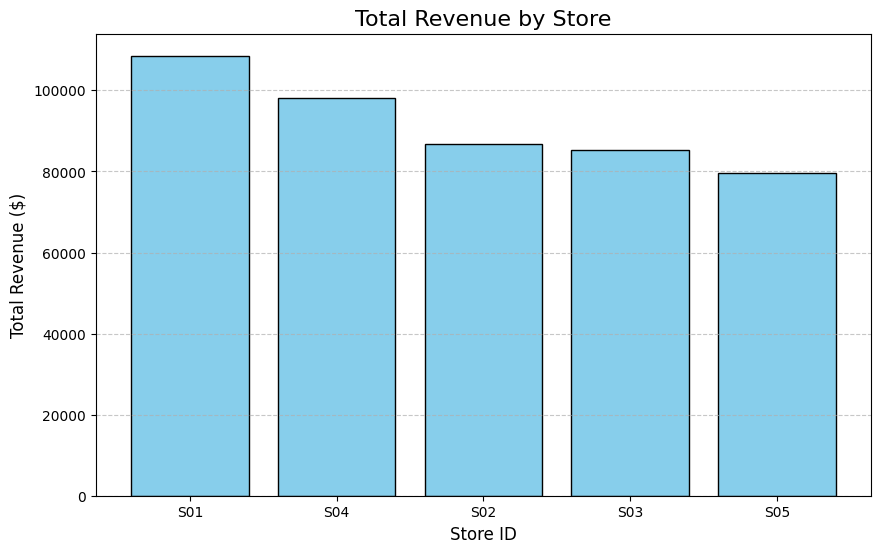

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(store_performance['store_id'], store_performance['total_revenue'], color='skyblue', edgecolor='black')
plt.title('Total Revenue by Store', fontsize=16)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

============================================================
# 8. WEEKLY REVENUE TREND
============================================================

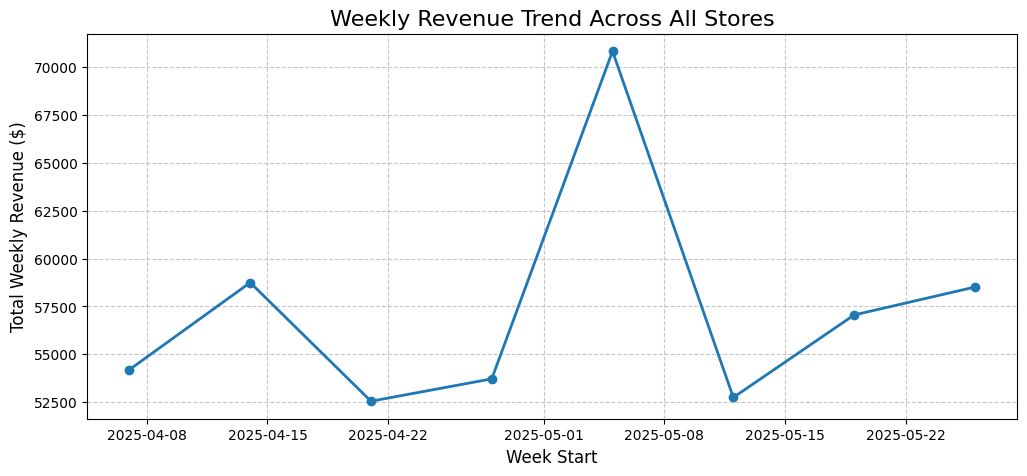

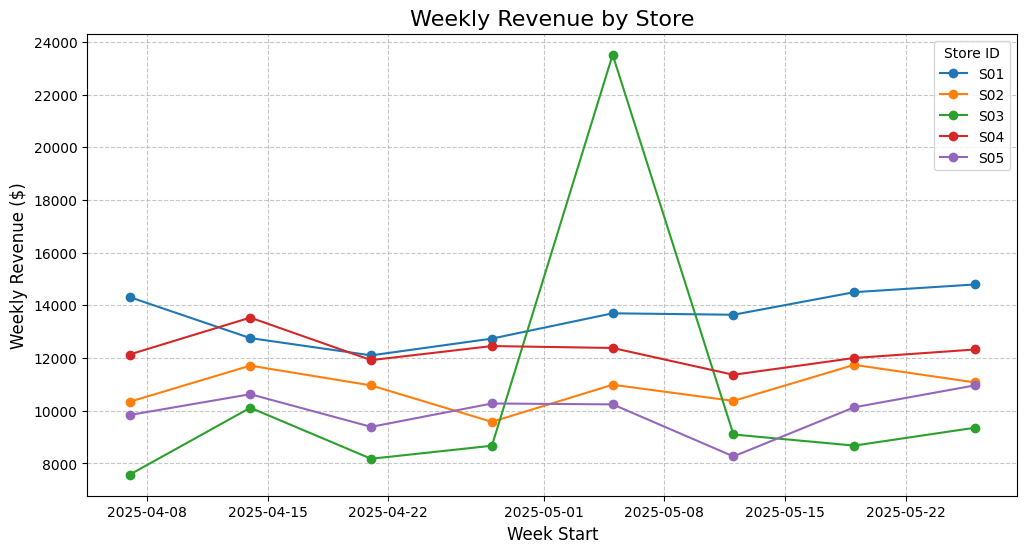

In [17]:
# Trend across all stores
weekly_trend = df.groupby('week_start')['weekly_revenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(weekly_trend['week_start'], weekly_trend['weekly_revenue'], marker='o', linestyle='-', linewidth=2)
plt.title('Weekly Revenue Trend Across All Stores', fontsize=16)
plt.xlabel('Week Start', fontsize=12)
plt.ylabel('Total Weekly Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Revenue by store over time
plt.figure(figsize=(12, 6))
for store in df['store_id'].unique():
    store_data = df[df['store_id'] == store].sort_values('week_start')
    plt.plot(store_data['week_start'], store_data['weekly_revenue'], marker='o', label=store)

plt.title('Weekly Revenue by Store', fontsize=16)
plt.xlabel('Week Start', fontsize=12)
plt.ylabel('Weekly Revenue ($)', fontsize=12)
plt.legend(title='Store ID')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

============================================================
# 9. WEEK-OVER-WEEK CHANGE
============================================================

In [18]:
df = df.sort_values(by=['store_id', 'week_start'])

# Calculate week-over-week changes
df['previous_week_revenue'] = df.groupby('store_id')['weekly_revenue'].shift(1)
df['revenue_change'] = df['weekly_revenue'] - df['previous_week_revenue']

# Only calculate percentage growth when previous-week revenue is non-zero
df['revenue_growth_pct'] = np.where(
    df['previous_week_revenue'] > 0,
    df['revenue_change'] / df['previous_week_revenue'],
    np.nan
)

# Identify largest positive and negative movements
largest_positive = df.nlargest(3, 'revenue_growth_pct')[['store_id', 'week_start', 'previous_week_revenue', 'weekly_revenue', 'revenue_change', 'revenue_growth_pct']]
largest_negative = df.nsmallest(3, 'revenue_growth_pct')[['store_id', 'week_start', 'previous_week_revenue', 'weekly_revenue', 'revenue_change', 'revenue_growth_pct']]

print("Largest Positive Week-over-Week Movements:")
display(largest_positive)

print("\nLargest Negative Week-over-Week Movements:")
display(largest_negative)

Largest Positive Week-over-Week Movements:


,store_id,week_start,previous_week_revenue,weekly_revenue,revenue_change,revenue_growth_pct
20,S03,2025-05-05,8671.07,23516.04,14844.97,1.71
17,S03,2025-04-14,7570.76,10113.42,2542.66,0.34
38,S05,2025-05-19,8265.98,10131.13,1865.15,0.23



Largest Negative Week-over-Week Movements:


,store_id,week_start,previous_week_revenue,weekly_revenue,revenue_change,revenue_growth_pct
21,S03,2025-05-12,23516.04,9097.82,-14418.22,-0.61
37,S05,2025-05-12,10241.93,8265.98,-1975.95,-0.19
18,S03,2025-04-21,10113.42,8177.12,-1936.30,-0.19


============================================================
# 10. RETURN ANALYSIS
============================================================

Return Rate by Store:


,store_id,total_return_amount,total_revenue,overall_return_rate
4,S05,2276.14,79730.00,0.03
0,S01,2733.75,108550.32,0.03
2,S02,2153.27,86766.58,0.02
1,S04,2351.93,98122.81,0.02
3,S03,1628.08,85178.15,0.02


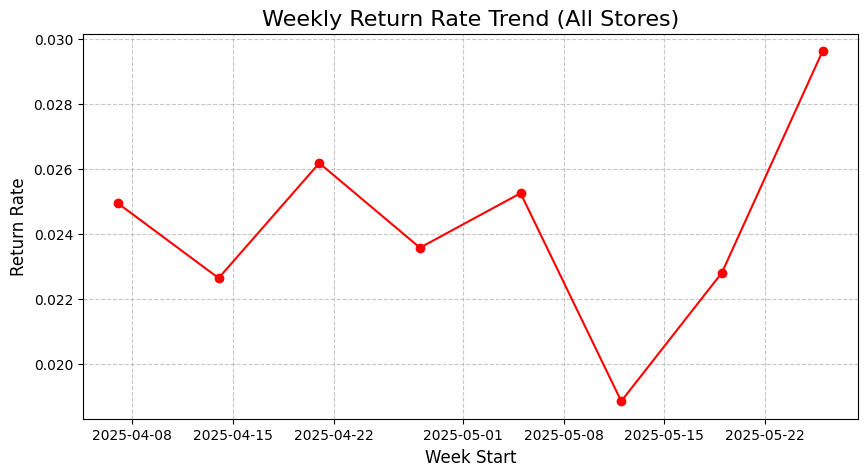

Highest Return Rate Store/Week Combinations (requires investigation):


,store_id,week_start,return_amount,weekly_revenue,return_rate
28,S04,2025-05-05,568.38,12382.98,0.05
3,S01,2025-04-28,482.81,12738.10,0.04
31,S04,2025-05-26,455.54,12325.09,0.04



Lowest Return Rate Store/Week Combinations:


,store_id,week_start,return_amount,weekly_revenue,return_rate
19,S03,2025-04-28,19.48,8671.07,0.00
29,S04,2025-05-12,107.11,11364.97,0.01
6,S01,2025-05-19,150.43,14501.11,0.01


In [19]:
# 1. Return rate by store
store_returns = store_performance[['store_id', 'total_return_amount', 'total_revenue', 'overall_return_rate']].copy()
print("Return Rate by Store:")
display(store_returns.sort_values('overall_return_rate', ascending=False))

# 2. Weekly return rate trend
weekly_returns = df.groupby('week_start').agg(
    total_return=('return_amount', 'sum'),
    total_revenue=('weekly_revenue', 'sum')
).reset_index()
weekly_returns['return_rate'] = weekly_returns['total_return'] / weekly_returns['total_revenue']

plt.figure(figsize=(10, 5))
plt.plot(weekly_returns['week_start'], weekly_returns['return_rate'], marker='o', color='red')
plt.title('Weekly Return Rate Trend (All Stores)', fontsize=16)
plt.xlabel('Week Start', fontsize=12)
plt.ylabel('Return Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 3. Identify highest and lowest return-rate store/week combinations
valid_returns = df[df['return_rate'].notna()]
highest_returns = valid_returns.nlargest(3, 'return_rate')[['store_id', 'week_start', 'return_amount', 'weekly_revenue', 'return_rate']]
lowest_returns = valid_returns.nsmallest(3, 'return_rate')[['store_id', 'week_start', 'return_amount', 'weekly_revenue', 'return_rate']]

print("Highest Return Rate Store/Week Combinations (requires investigation):")
display(highest_returns)

print("\nLowest Return Rate Store/Week Combinations:")
display(lowest_returns)

============================================================
# 11. STAFFING EFFICIENCY
============================================================

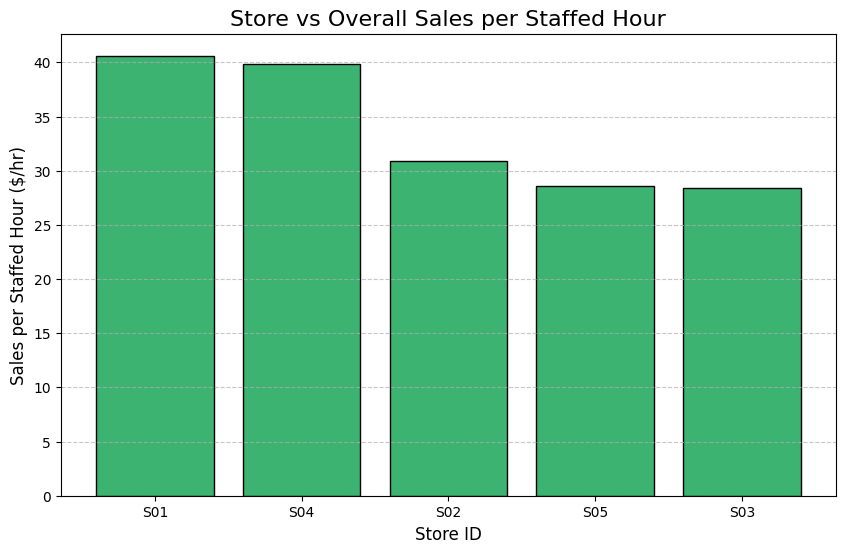

Highest Efficiency Store: S01 ($40.61/hr)
Lowest Efficiency Store: S03 ($28.43/hr)


In [20]:
# We already calculated total staffing hours and overall sales per staffed hour in store_performance
staffing_eff = store_performance[['store_id', 'total_staffing_hours', 'overall_sales_per_staffed_hour']].copy()
# Sort for chart
staffing_eff = staffing_eff.sort_values('overall_sales_per_staffed_hour', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(staffing_eff['store_id'], staffing_eff['overall_sales_per_staffed_hour'], color='mediumseagreen', edgecolor='black')
plt.title('Store vs Overall Sales per Staffed Hour', fontsize=16)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Sales per Staffed Hour ($/hr)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

highest_eff = staffing_eff.iloc[0]
lowest_eff = staffing_eff.iloc[-1]

print(f"Highest Efficiency Store: {highest_eff['store_id']} (${highest_eff['overall_sales_per_staffed_hour']:.2f}/hr)")
print(f"Lowest Efficiency Store: {lowest_eff['store_id']} (${lowest_eff['overall_sales_per_staffed_hour']:.2f}/hr)")

============================================================
# 12. INVESTIGATE UNUSUAL PATTERNS
============================================================

In [21]:
# A. S03 / 2025-05-05
print("A. Investigating S03 around 2025-05-05 (Unusual pattern requiring investigation):")
s03_weeks = pd.to_datetime(['2025-04-28', '2025-05-05', '2025-05-12'])
s03_investigation = df[(df['store_id'] == 'S03') & (df['week_start'].isin(s03_weeks))]
cols_to_show = ['store_id', 'week_start', 'weekly_revenue', 'transaction_count', 'return_amount', 'return_rate', 'staffing_hours', 'sales_per_staffed_hour']
display(s03_investigation[cols_to_show])

# B. S04 / 2025-05-12
print("\nB. Investigating S04 around 2025-05-12 (Missing staffing data):")
s04_weeks = pd.to_datetime(['2025-05-05', '2025-05-12', '2025-05-19'])
s04_investigation = df[(df['store_id'] == 'S04') & (df['week_start'].isin(s04_weeks))]
display(s04_investigation[cols_to_show])

A. Investigating S03 around 2025-05-05 (Unusual pattern requiring investigation):


,store_id,week_start,weekly_revenue,transaction_count,return_amount,return_rate,staffing_hours,sales_per_staffed_hour
19,S03,2025-04-28,8671.07,165,19.48,0.00,375.50,23.09
20,S03,2025-05-05,23516.04,304,341.36,0.01,416.80,56.42
21,S03,2025-05-12,9097.82,170,130.32,0.01,383.50,23.72



B. Investigating S04 around 2025-05-12 (Missing staffing data):


,store_id,week_start,weekly_revenue,transaction_count,return_amount,return_rate,staffing_hours,sales_per_staffed_hour
28,S04,2025-05-05,12382.98,237,568.38,0.05,357.30,34.66
29,S04,2025-05-12,11364.97,223,107.11,0.01,NaN,NaN
30,S04,2025-05-19,12002.61,221,287.93,0.02,357.00,33.62


============================================================
# 13. STORE SCORECARD
============================================================

In [22]:
scorecard = store_performance[['store_id', 'total_revenue', 'total_transactions', 'overall_return_rate', 'total_staffing_hours', 'overall_sales_per_staffed_hour']].copy()
display(scorecard)

,store_id,total_revenue,total_transactions,overall_return_rate,total_staffing_hours,overall_sales_per_staffed_hour
0,S01,108550.32,2024,0.03,2672.90,40.61
1,S04,98122.81,1834,0.02,2461.00,39.87
2,S02,86766.58,1627,0.02,2812.20,30.85
3,S03,85178.15,1469,0.02,2995.80,28.43
4,S05,79730.00,1482,0.03,2784.80,28.63


============================================================
# 14. FINDING CANDIDATES
============================================================

*Thresholds:*
- High return rate threshold > 0.05 (5%)
- Week-over-week revenue spike > 0.20 (20%)

In [25]:
findings = []

# Revenue spikes
for _, row in df[df['revenue_growth_pct'] > 0.20].iterrows():
    findings.append({
        'finding_type': 'revenue_spike',
        'store_id': row['store_id'],
        'week_start': row['week_start'].strftime('%Y-%m-%d'),
        'metric': 'revenue_growth_pct',
        'value': row['revenue_growth_pct'],
        'comparison': 'Previous week',
        'notes': f"Revenue spiked {row['revenue_growth_pct']:.1%} WoW"
    })

# High return rates
top_return_rate_weeks = (
    df[
        [
            'store_id',
            'week_start',
            'return_rate',
            'weekly_revenue',
            'return_amount',
            'return_count'
        ]
    ]
    .sort_values('return_rate', ascending=False)
    .head(3)
)
for _, row in top_return_rate_weeks.iterrows():
     findings.append({
        'finding_type': 'high_return_rate',
        'store_id': row['store_id'],
        'week_start': row['week_start'].strftime('%Y-%m-%d'),
        'metric': 'return_rate',
        'value': row['return_rate'],
        'comparison': 'Top 3 return-rate store-weeks in the dataset',
        'notes': (
            f"Return rate of {row['return_rate']:.1%} "
            f"is among the highest observed in the dataset"
        )
    })

# Missing staffing
for _, row in df[df['staffing_hours'].isna()].iterrows():
    findings.append({
        'finding_type': 'missing_staffing_data',
        'store_id': row['store_id'],
        'week_start': row['week_start'].strftime('%Y-%m-%d'),
        'metric': 'staffing_hours',
        'value': np.nan,
        'comparison': 'Missing staffing data',
        'notes': "Staffing hours missing for this week"
    })

findings_df = pd.DataFrame(findings)
display(findings_df)

,finding_type,store_id,week_start,metric,value,comparison,notes
0,revenue_spike,S03,2025-04-14,revenue_growth_pct,0.34,Previous week,Revenue spiked 33.6% WoW
1,revenue_spike,S03,2025-05-05,revenue_growth_pct,1.71,Previous week,Revenue spiked 171.2% WoW
2,revenue_spike,S05,2025-05-19,revenue_growth_pct,0.23,Previous week,Revenue spiked 22.6% WoW
3,high_return_rate,S04,2025-05-05,return_rate,0.05,Top 3 return-rate store-weeks in the dataset,Return rate of 4.6% is among the highest obser...
4,high_return_rate,S01,2025-04-28,return_rate,0.04,Top 3 return-rate store-weeks in the dataset,Return rate of 3.8% is among the highest obser...
5,high_return_rate,S04,2025-05-26,return_rate,0.04,Top 3 return-rate store-weeks in the dataset,Return rate of 3.7% is among the highest obser...
6,missing_staffing_data,S04,2025-05-12,staffing_hours,NaN,Missing staffing data,Staffing hours missing for this week


============================================================
# 15. TOP 1-3 BUSINESS FINDINGS
============================================================

1. **S03 Unusual Revenue Spike**
   - **What happened:** S03 generated substantially higher revenue in the week of 2025-05-05.
   - **Where it happened:** Store S03.
   - **When it happened:** Week starting 2025-05-05.
   - **Supporting metric:** Week-over-week revenue growth percentage.
   - **Comparison/baseline:** Surrounding weeks (2025-04-28 and 2025-05-12) for S03.
   - **Why it may matter:** Represents a significant deviation from normal operations that dramatically skews overall store efficiency.
   - **What should be investigated next:** Need to identify what operations, inventory availability, or promotions were active that week.

2. **Missing Staffing Data for S04**
   - **What happened:** Staffing hours data is entirely missing.
   - **Where it happened:** Store S04.
   - **When it happened:** Week starting 2025-05-12.
   - **Supporting metric:** `staffing_hours` is NaN.
   - **Comparison/baseline:** All other 39 store-week rows have populated staffing hours.
   - **Why it may matter:** Creates a blind spot in overall efficiency (sales per staffed hour) for this store and week.
   - **What should be investigated next:** Check the time-and-attendance system logs to see why shifts were not recorded for S04 during this week.

3. **Persistent Efficiency Gap Between Stores**
   - **What happened:** There is a large variance in overall sales per staffed hour across the 5 stores.
   - **Where it happened:** Across the entire network.
   - **When it happened:** Throughout the 8-week period.
   - **Supporting metric:** `overall_sales_per_staffed_hour`.
   - **Comparison/baseline:** Highest vs lowest efficiency stores in the network.
   - **Why it may matter:** Suggests potential for optimizing labor allocation or sharing best practices from high-efficiency stores to low-efficiency ones.
   - **What should be investigated next:** Are there structural differences (store size, location, typical basket size) causing the efficiency gap?

============================================================
# 16. BUSINESS QUESTIONS TO CARRY FORWARD
============================================================

- What may explain the S03 revenue spike during the week of 2025-05-05?
- Is the unusually high S03 sales-per-staffed-hour during that week sustainable?
- Why is S04 staffing data missing for 2025-05-12?
- Are elevated return rates concentrated in particular stores or weeks?
- Are revenue changes accompanied by proportional changes in staffing hours?

============================================================
# 17. FINAL TRUSTED DATASET SUMMARY
============================================================

In [13]:
total_revenue = df['weekly_revenue'].sum()
total_transactions = df['transaction_count'].sum()
total_return_amount = df['return_amount'].sum()
total_staffing_hours = df['staffing_hours'].sum()

print(f"Number of stores: {df['store_id'].nunique()}")
print(f"Number of weeks: {df['week_start'].nunique()}")
print(f"Number of store-week rows: {len(df)}")
print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Total transactions: {total_transactions:,}")
print(f"Total return amount: ${total_return_amount:,.2f}")
print(f"Overall return rate: {(total_return_amount / total_revenue):.2%}")
print(f"Total staffing hours: {total_staffing_hours:,.2f}")

Number of stores: 5
Number of weeks: 8
Number of store-week rows: 40
Total revenue: $458,347.86
Total transactions: 8,436
Total return amount: $11,143.17
Overall return rate: 2.43%
Total staffing hours: 13,726.70


============================================================
# 18. FINAL NOTEBOOK CONCLUSION
============================================================

- The `weekly_metrics.csv` dataset is fully validated.
- The dataset successfully presents a consistent store × week grain.
- We have identified main business patterns, including structural efficiency differences and specific anomalous weeks requiring investigation.
- Known limitations include missing staffing data for S04 and data cleaning artifacts (duplicate/invalid rows) removed prior to this analysis.
- The next stage will use these trusted findings as input to an LLM.
- The LLM should explain and summarize these validated metrics rather than attempt to calculate them from raw transaction data.